# Participation Coefficient Analysis 

analysis from numberline/group_comparison_01.ipynb for DNumRisk

PC = How much are nodes connected to other modules... (1- [inter/intra FC])


In [87]:
import nibabel as nib
import numpy as np
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
dataset_name = 'DNumRisk'
ses = 1

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
subArray = [sub for sub in range(1, 67)]


In [102]:
group_mapping = pd.read_csv(os.path.join(bids_folder, 'group_assignment.csv')).set_index('subject')

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
#mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

ci = glasser_CAatlas_mapping['ca_network'].values # community affiliation vector

In [103]:
from utils import threshold_matrix
conn_thresh = 0.15  # Proportion of connections to keep
post_preproc = '36P'

CMs = []
subArray = []
for sub in subList:
    try:
        cm = np.load(os.path.join(bids_folder, 'derivatives', 'correlation_matrices.parcel', f'sub-{sub}_glasserParcel-fsaverage_confspec-36Pscrub3BPfilter.npy'))  # generated with getCM_parcel.py
        cm = threshold_matrix(cm, proportion=conn_thresh)  # Threshold the matrix to keep only the top 15% of connections
        CMs.append(cm)
        subArray.append(sub)
    except FileNotFoundError:
        print(f"File not found for subject {sub}")
subArray = np.array(subArray).astype(int)

In [104]:
from utils import participation_coef, threshold_matrix

df_PCs = []
df_meanNet_PCs = []
net_names = CAatlas_names['Network Name'].values

for cm in CMs:
    part_coefs = participation_coef(cm, ci)
    sub_meanNet_PCs = []
    for i_net in CAatlas_names.index.values:
        mask = (ci == i_net)
        sub_meanNet_PCs.append(part_coefs[mask].mean())
    df_meanNet_PCs.append(sub_meanNet_PCs)
    df_PCs.append(part_coefs) 

df_PCs = pd.DataFrame(df_PCs, index=subArray, columns=[f'parcel_{i}' for i in range(len(ci))])   
df_meanNet_PCs = pd.DataFrame(df_meanNet_PCs, index=subArray, columns=net_names)
df_meanNet_PCs.index.name = 'subject'

df_meanNet_PCs = df_meanNet_PCs.join(group_mapping, on='subject')

/home/ubuntu/git/parietal_patterns/common_connectivity_stuff/utils.py:43: RuntimeWarning: invalid value encountered in divide
  P = np.ones((n,)) - (Kc2 / np.square(Ko))  # divide


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)

Text(0.5, 1.2, 'DNumRisk Study \n Participation Coefficient by Network - Group Comparisons \n thresh=0.15')

/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 12.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


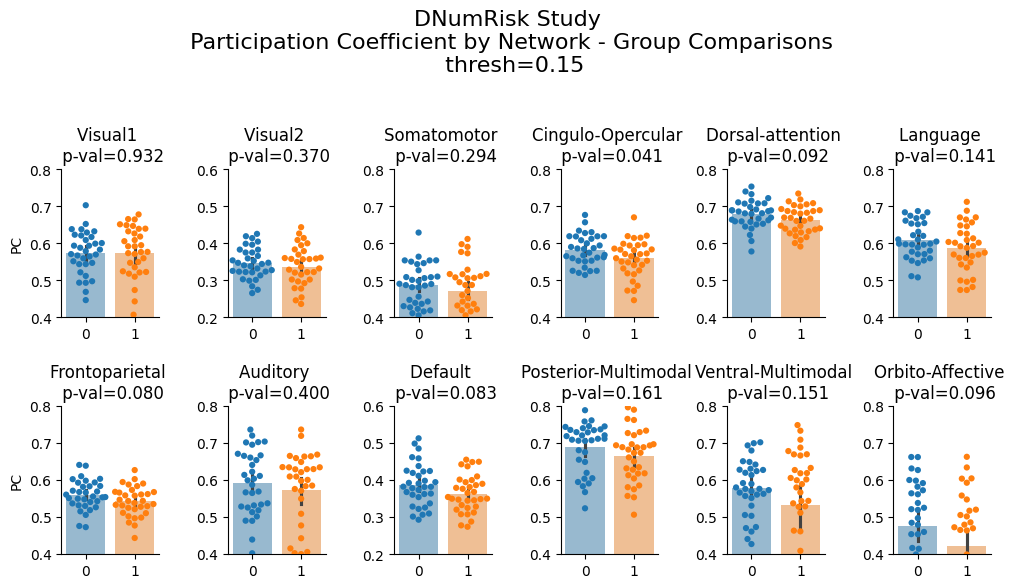

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

fig, axs = plt.subplots(2,6, figsize=(12,5))
axs = axs.flatten()

tmp = df_meanNet_PCs.set_index('group',append=True)

for i, net in enumerate(net_names):
        y_var = net
        sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False,ax=axs[i])
        sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=4.5,legend=False,ax=axs[i])
        stats = ttest_ind(tmp.xs(0,0,'group')[net], tmp.xs(1,0,'group')[net], axis=0, equal_var=False)
        axs[i].set(title=f'{y_var} \n p-val={stats.pvalue:.3f}', xlabel=None,ylim=(.4,.8))
        axs[i].set(ylabel='PC') if i == 0 or i == 6 else axs[i].set(ylabel=None)
        sns.despine()
axs[1].set(ylim=(.2,.6)) # visual2 is different
axs[8].set(ylim=(.2,.6)) # DMN is different

fig.subplots_adjust(hspace=0.6, wspace=0.7)
fig.suptitle(f'{dataset_name} Study \n Participation Coefficient by Network - Group Comparisons \n thresh={conn_thresh}', fontsize=16, y= 1.2)